# Data Preparation & Exploratory Data Analysis

**Input:** `outputs/enriched_bac_data.csv` — produit par le notebook 01  
**Outputs:** `data/bac_panel.csv` · `data/bac_crosssectional.csv`  

**Colonnes disponibles depuis NB01:**  
`gov_fr, Code, population, nb_primaires, nb_colleges, nb_lycees, nb_total,`  
`primaires_per_1k, colleges_per_1k, lycees_per_1k, schools_per_1k,`  
`poverty_rate, illiteracy_rate, rate_mean, rate_trend, rate_volatility,`  
`2018_Rate … 2025_Rate, 2018_Rank … 2025_Rank`

> **Note:** Les colonnes `Present` et `Pass` ne sont pas dans l'export NB01.  
> Le panel est donc construit sur `Rate` et `Rank` uniquement.

---

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

import os
os.makedirs('../data', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

print('✅ Libraries loaded')

✅ Libraries loaded


## 1. Chargement et inspection

In [13]:
df_raw = pd.read_csv('../data/enriched/enriched_bac_data.csv')

print(f'Shape: {df_raw.shape}')
print(f'Colonnes: {df_raw.columns.tolist()}')

missing = df_raw.isnull().sum()
if missing.sum() > 0:
    print(f'\n⚠️ Valeurs manquantes:\n{missing[missing > 0]}')
else:
    print('\n✅ Aucune valeur manquante')

df_raw.head(3)

Shape: (26, 27)
Colonnes: ['gov_fr', 'Code', 'population', 'pop_15_19_est', 'nb_lycees', 'lycees_per_1k', 'poverty_rate', 'illiteracy_rate', 'rate_mean', 'rate_trend', 'rate_volatility', '2018_Rate', '2019_Rate', '2020_Rate', '2021_Rate', '2022_Rate', '2023_Rate', '2024_Rate', '2025_Rate', '2018_Rank', '2019_Rank', '2020_Rank', '2021_Rank', '2022_Rank', '2023_Rank', '2024_Rank', '2025_Rank']

✅ Aucune valeur manquante


,gov_fr,Code,population,pop_15_19_est,nb_lycees,lycees_per_1k,poverty_rate,illiteracy_rate,rate_mean,rate_trend,...,2024_Rate,2025_Rate,2018_Rank,2019_Rank,2020_Rank,2021_Rank,2022_Rank,2023_Rank,2024_Rank,2025_Rank
0,Sfax 1,71,514182,36250,25,0.690,8.3,17.1,54.46,1.796,...,62.63,55.75,1,3,2,2,1,1,2,1
1,Sfax 2,72,514182,36250,19,0.524,8.3,17.1,54.08,1.737,...,63.39,54.89,2,1,1,1,2,2,1,2
2,Monastir,83,611118,43084,28,0.650,8.6,11.7,49.25,1.340,...,58.16,45.63,4,2,3,3,3,7,4,10


## 2. Construction du format panel (long)

On passe du format large (1 ligne par gouvernorat) au format panel (1 ligne par gouvernorat × année).  
Résultat attendu : **208 lignes** (26 gouvernorats × 8 années).

In [14]:
YEARS = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

# Colonnes socioéconomiques statiques disponibles dans NB01
STATIC_COLS = [
    'nb_lycees', 'lycees_per_1k', 'poverty_rate', 'illiteracy_rate', 'population'
]

records = []
for _, row in df_raw.iterrows():
    for year in YEARS:
        record = {
            'governorate': row['gov_fr'],
            'code':        row['Code'],
            'year':        year,
            'rank':        row[f'{year}_Rank'],
            'success_rate': row[f'{year}_Rate'],
        }
        for col in STATIC_COLS:
            record[col] = row[col]
        records.append(record)

df_panel = pd.DataFrame(records)

# Identifier les gouvernorats dupliqués (Sfax 1/2, Tunis 1/2)
df_panel['is_split_gov'] = df_panel['governorate'].str.contains(r' [12]$', regex=True)

print(f'✅ Panel shape: {df_panel.shape}  ({len(YEARS)} années × {len(df_raw)} gouvernorats)')
print(f'   Colonnes: {df_panel.columns.tolist()}')
df_panel.head(8)

✅ Panel shape: (208, 11)  (8 années × 26 gouvernorats)
   Colonnes: ['governorate', 'code', 'year', 'rank', 'success_rate', 'nb_lycees', 'lycees_per_1k', 'poverty_rate', 'illiteracy_rate', 'population', 'is_split_gov']


,governorate,code,year,rank,success_rate,nb_lycees,lycees_per_1k,poverty_rate,illiteracy_rate,population,is_split_gov
0,Sfax 1,71,2018,1,55.88,25,0.69,8.3,17.1,514182,True
1,Sfax 1,71,2019,3,43.01,25,0.69,8.3,17.1,514182,True
2,Sfax 1,71,2020,2,37.02,25,0.69,8.3,17.1,514182,True
3,Sfax 1,71,2021,2,64.36,25,0.69,8.3,17.1,514182,True
4,Sfax 1,71,2022,1,60.95,25,0.69,8.3,17.1,514182,True
5,Sfax 1,71,2023,1,56.05,25,0.69,8.3,17.1,514182,True
6,Sfax 1,71,2024,2,62.63,25,0.69,8.3,17.1,514182,True
7,Sfax 1,71,2025,1,55.75,25,0.69,8.3,17.1,514182,True


## 3. Ingénierie des features

On crée les variables dérivées qui capturent la dynamique cachée dans les valeurs brutes annuelles.  
Note : `rate_mean`, `rate_trend`, `rate_volatility` sont déjà calculés par NB01 — on les récupère directement.

In [15]:
# ── Récupérer les features temporelles déjà calculées par NB01 ──────────────
nb01_features = df_raw[['gov_fr', 'rate_mean', 'rate_trend', 'rate_volatility']].copy()
nb01_features = nb01_features.rename(columns={
    'gov_fr':          'governorate',
    'rate_mean':       'mean_rate',
    'rate_trend':      'trend_slope',
    'rate_volatility': 'std_rate',
})

# ── Features supplémentaires calculées ici ──────────────────────────────────

# Min / max / meilleur et pire rang
gov_extra = df_panel.groupby('governorate').agg(
    min_rate=('success_rate', 'min'),
    max_rate=('success_rate', 'max'),
    best_rank=('rank', 'min'),
    worst_rank=('rank', 'max'),
).reset_index()

# Ratio de récupération COVID : (taux 2021 - taux 2020) / taux 2020 × 100
rate_2020 = df_panel[df_panel['year'] == 2020].set_index('governorate')['success_rate']
rate_2021 = df_panel[df_panel['year'] == 2021].set_index('governorate')['success_rate']
covid_recovery = ((rate_2021 - rate_2020) / rate_2020 * 100).reset_index()
covid_recovery.columns = ['governorate', 'covid_recovery_pct']

# Volatilité du rang (écart-type du rang national sur 8 ans)
rank_volatility = df_panel.groupby('governorate')['rank'].std().reset_index()
rank_volatility.columns = ['governorate', 'rank_volatility']

# Features socioéconomiques statiques (dédupliquées)
socio_static = df_panel.drop_duplicates('governorate')[[
    'governorate', 'nb_lycees','lycees_per_1k', 
    'poverty_rate', 'illiteracy_rate', 'population'
]].copy()

# ── Assemblage du dataframe cross-sectionnel (1 ligne par gouvernorat) ──────
df_gov = nb01_features \
    .merge(gov_extra,       on='governorate') \
    .merge(covid_recovery,  on='governorate') \
    .merge(rank_volatility, on='governorate') \
    .merge(socio_static,    on='governorate')

print(f'✅ Cross-sectional shape: {df_gov.shape}')
print(f'   Colonnes: {df_gov.columns.tolist()}')
df_gov.round(3)

✅ Cross-sectional shape: (26, 15)
   Colonnes: ['governorate', 'mean_rate', 'trend_slope', 'std_rate', 'min_rate', 'max_rate', 'best_rank', 'worst_rank', 'covid_recovery_pct', 'rank_volatility', 'nb_lycees', 'lycees_per_1k', 'poverty_rate', 'illiteracy_rate', 'population']


,governorate,mean_rate,trend_slope,std_rate,min_rate,max_rate,best_rank,worst_rank,covid_recovery_pct,rank_volatility,nb_lycees,lycees_per_1k,poverty_rate,illiteracy_rate,population
0,Sfax 1,54.46,1.796,9.62,37.02,64.36,1,3,73.852,0.744,25,0.690,8.3,17.1,514182
1,Sfax 2,54.08,1.737,8.54,39.73,64.53,1,2,62.421,0.535,19,0.524,8.3,17.1,514182
2,Monastir,49.25,1.340,9.07,35.30,63.30,2,10,79.320,2.673,28,0.650,8.6,11.7,611118
3,Mahdia,46.88,2.243,10.00,32.78,62.48,3,10,90.604,2.066,23,0.728,17.6,22.2,448273
4,Sousse,47.52,1.725,8.94,33.34,60.69,3,7,82.034,1.126,29,0.546,12.3,13.6,753670
5,Ariana,47.88,1.410,7.27,34.41,57.27,3,6,66.434,1.069,22,0.463,7.4,11.3,674025
6,Nabeul,44.00,1.907,8.71,29.17,56.66,7,12,94.241,1.727,24,0.390,6.7,15.7,873824
7,Tunis 1,44.92,2.231,9.29,29.37,56.40,6,10,92.033,1.506,29,0.763,4.6,11.2,539206
8,Médenine,44.44,2.524,9.02,29.94,55.32,3,11,84.770,2.560,32,0.869,19.3,16.2,522294
9,Tunis 2,42.11,1.905,9.80,26.49,55.31,9,13,108.796,1.604,18,0.474,4.6,11.2,539206


## 4. Tendance nationale — Impact COVID et récupération

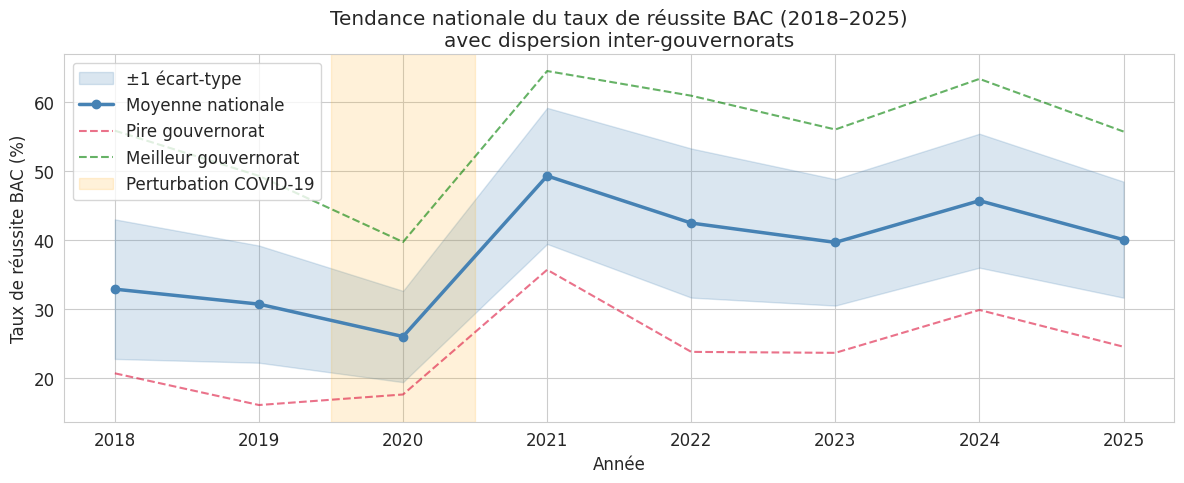

Saved: outputs/visualisations/02_national_trend.png


In [16]:
national = df_panel.groupby('year')['success_rate'].agg(
    mean='mean', std='std', min='min', max='max'
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(national['year'],
                national['mean'] - national['std'],
                national['mean'] + national['std'],
                alpha=0.2, color='steelblue', label='±1 écart-type')
ax.plot(national['year'], national['mean'], 'o-', color='steelblue',
        linewidth=2.5, label='Moyenne nationale')
ax.plot(national['year'], national['min'], '--', color='crimson',
        alpha=0.6, label='Pire gouvernorat')
ax.plot(national['year'], national['max'], '--', color='green',
        alpha=0.6, label='Meilleur gouvernorat')
ax.axvspan(2019.5, 2020.5, color='orange', alpha=0.15, label='Perturbation COVID-19')
ax.set_xlabel('Année')
ax.set_ylabel('Taux de réussite BAC (%)')
ax.set_title('Tendance nationale du taux de réussite BAC (2018–2025)\navec dispersion inter-gouvernorats')
ax.legend()
ax.set_xticks(YEARS)
plt.tight_layout()
plt.savefig('../outputs/visualisations/02_national_trend.png', dpi=150)
plt.show()
print('Saved: outputs/visualisations/02_national_trend.png')

## 5. Inégalité dans le temps — L'écart se réduit-il ?

**Question de fouille:** L'inégalité éducative régionale augmente-t-elle ou diminue-t-elle sur la période ?

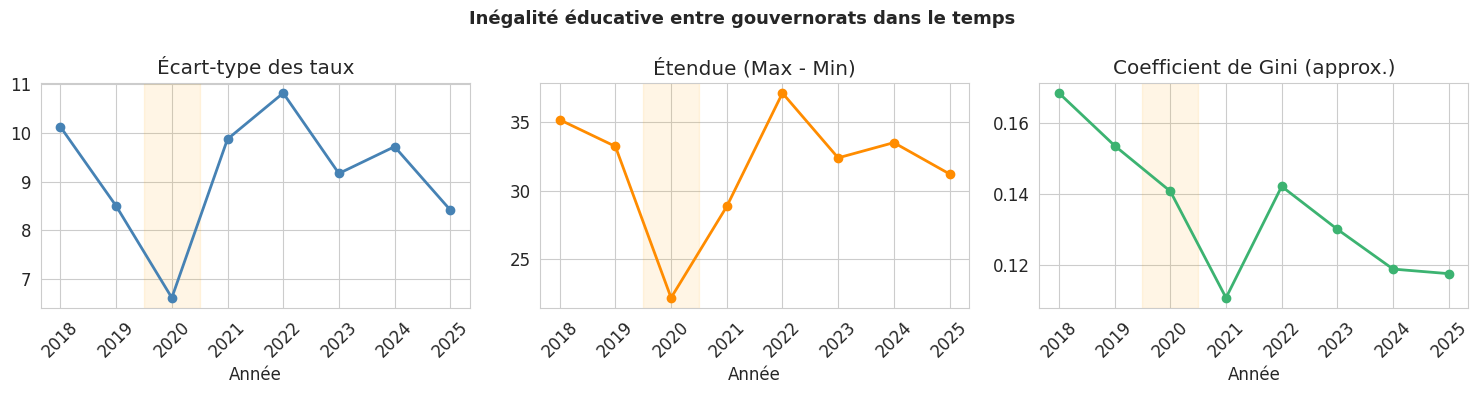


Résultat clé:
  Écart-type 2018 : 10.12%
  Écart-type 2025 : 8.42%
  Conclusion : L'inégalité inter-gouvernorats DIMINUE ✅


In [17]:
inequality = df_panel.groupby('year').agg(
    std_rate=('success_rate', 'std'),
    range_rate=('success_rate', lambda x: x.max() - x.min()),
    gini_approx=('success_rate', lambda x: (
        2 * np.sum(np.arange(1, len(x)+1) * np.sort(x))
        / (len(x) * np.sum(x)) - (len(x)+1)/len(x)
    ))
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title, color in zip(
    axes,
    ['std_rate', 'range_rate', 'gini_approx'],
    ['Écart-type des taux', 'Étendue (Max - Min)', 'Coefficient de Gini (approx.)'],
    ['steelblue', 'darkorange', 'mediumseagreen']
):
    ax.plot(inequality['year'], inequality[col], 'o-', color=color, linewidth=2)
    ax.axvspan(2019.5, 2020.5, color='orange', alpha=0.1)
    ax.set_title(title)
    ax.set_xlabel('Année')
    ax.set_xticks(YEARS)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Inégalité éducative entre gouvernorats dans le temps', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/visualisations/02_inequality_over_time.png', dpi=150)
plt.show()

std_2018 = inequality[inequality.year==2018]['std_rate'].values[0]
std_2025 = inequality[inequality.year==2025]['std_rate'].values[0]
verdict = 'DIMINUE ✅' if std_2025 < std_2018 else 'AUGMENTE ⚠️'
print(f'\nRésultat clé:')
print(f'  Écart-type 2018 : {std_2018:.2f}%')
print(f'  Écart-type 2025 : {std_2025:.2f}%')
print(f'  Conclusion : L\'inégalité inter-gouvernorats {verdict}')

## 6. Matrice de corrélations

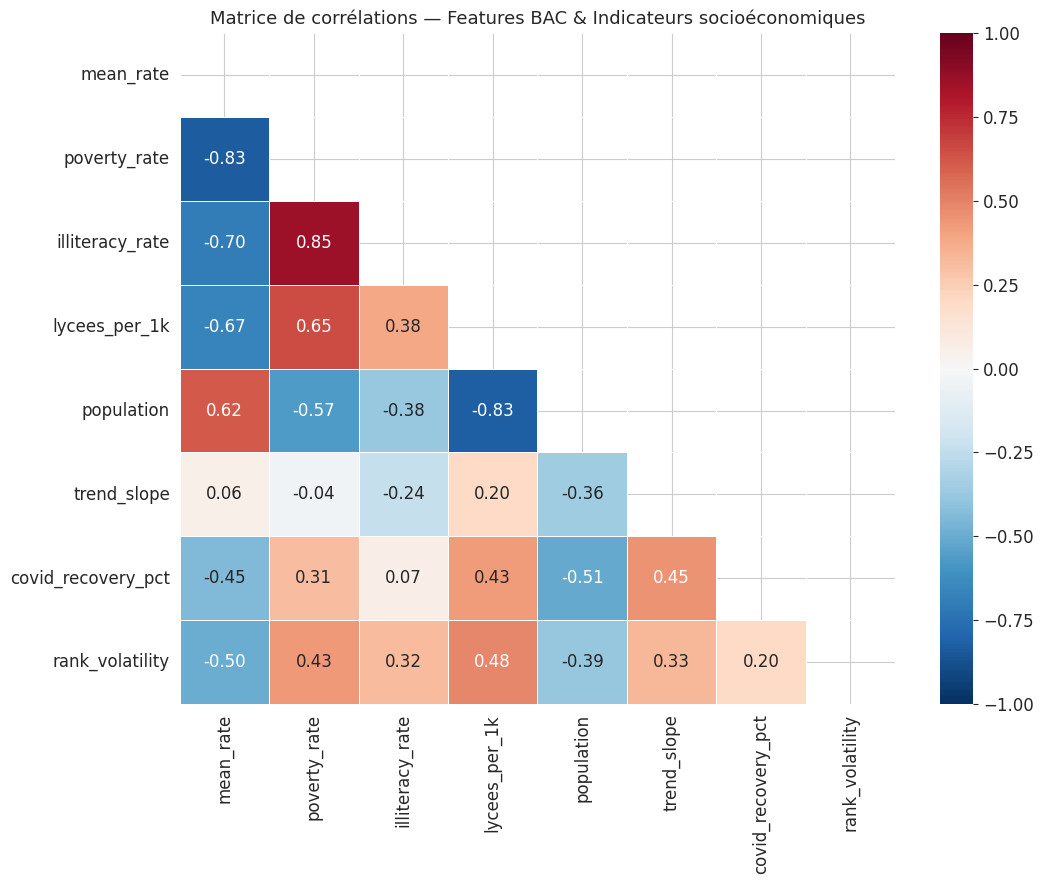


Corrélations avec le taux moyen de réussite (triées par valeur absolue) :
poverty_rate         -0.829
illiteracy_rate      -0.698
lycees_per_1k        -0.671
population            0.617
rank_volatility      -0.498
covid_recovery_pct   -0.445
trend_slope           0.059
Name: mean_rate, dtype: float64


In [18]:
corr_cols = [
    'mean_rate', 'poverty_rate', 'illiteracy_rate',
    'lycees_per_1k', 'population',
    'trend_slope', 'covid_recovery_pct', 'rank_volatility'
]

corr_matrix = df_gov[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    ax=ax, linewidths=0.5
)
ax.set_title('Matrice de corrélations — Features BAC & Indicateurs socioéconomiques', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/visualisations/02_correlation_matrix.png', dpi=150)
plt.show()

print('\nCorrélations avec le taux moyen de réussite (triées par valeur absolue) :')
print(corr_matrix['mean_rate'].drop('mean_rate')
      .sort_values(key=abs, ascending=False).round(3))

## 7. Heatmap trajectoires — tous les gouvernorats × toutes les années

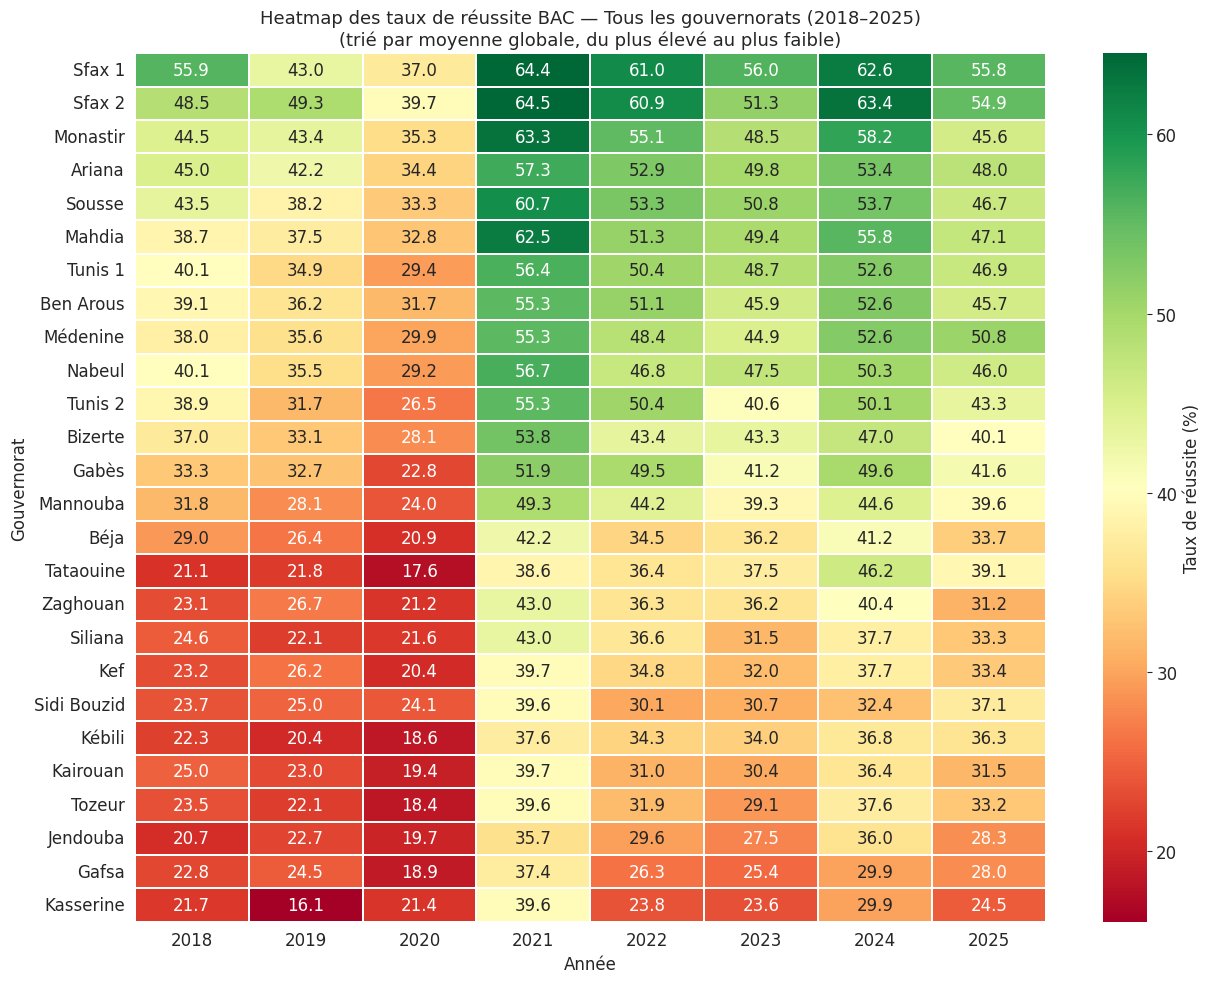

Saved: outputs/visualisations/02_trajectory_heatmap.png


In [19]:
pivot = df_panel.pivot(index='governorate', columns='year', values='success_rate')
pivot = pivot.loc[df_gov.sort_values('mean_rate', ascending=False)['governorate']]

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    pivot, annot=True, fmt='.1f', cmap='RdYlGn',
    ax=ax, linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Taux de réussite (%)'}
)
ax.set_title(
    'Heatmap des taux de réussite BAC — Tous les gouvernorats (2018–2025)\n'
    '(trié par moyenne globale, du plus élevé au plus faible)',
    fontsize=13
)
ax.set_xlabel('Année')
ax.set_ylabel('Gouvernorat')
plt.tight_layout()
plt.savefig('../outputs/visualisations/02_trajectory_heatmap.png', dpi=150)
plt.show()
print('Saved: outputs/visualisations/02_trajectory_heatmap.png')

## 8. Détection des sur-performants et sous-performants

**Question de fouille :** Quels gouvernorats performent systématiquement au-dessus ou en dessous de ce que leur profil socioéconomique prédit ? Ce sont les anomalies les plus intéressantes.

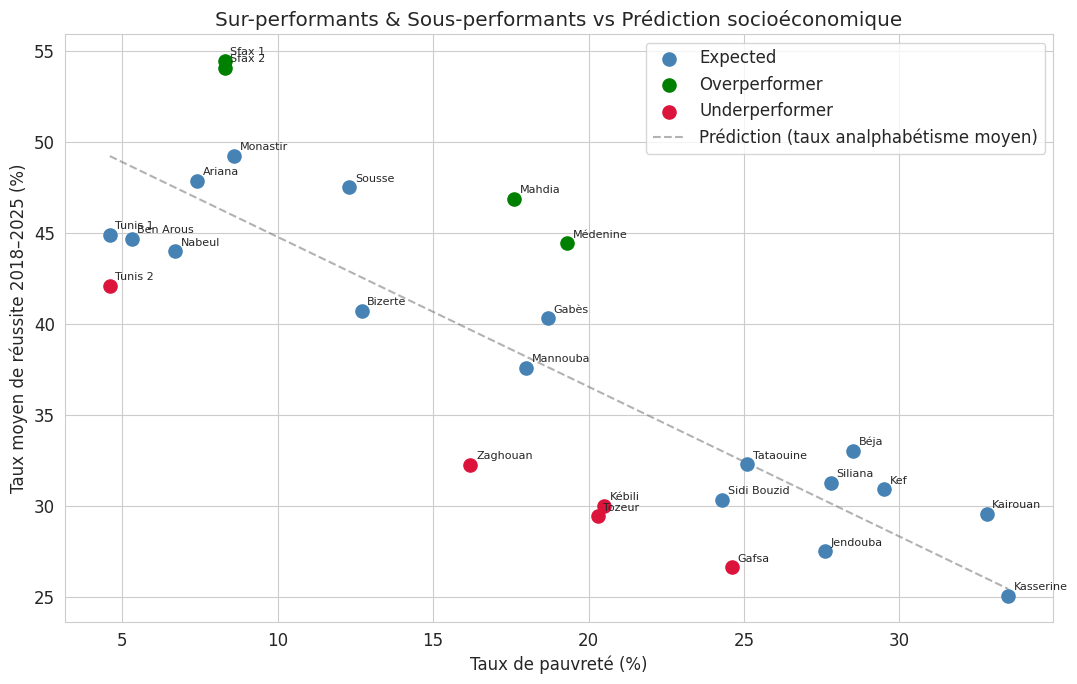


Sur-performants (au-dessus de la prédiction) :
governorate  mean_rate  predicted_rate  residual
     Sfax 1      54.46           46.07      8.39
     Sfax 2      54.08           46.07      8.01
     Mahdia      46.88           38.59      8.29
   Médenine      44.44           36.98      7.46

Sous-performants (en dessous de la prédiction) :
governorate  mean_rate  predicted_rate  residual
    Tunis 2      42.11           48.91     -6.80
   Zaghouan      32.28           39.91     -7.63
     Tozeur      29.44           36.13     -6.69
     Kébili      30.02           36.08     -6.06
      Gafsa      26.64           32.79     -6.15


In [20]:
# Modèle simple : prédire mean_rate depuis poverty + illiteracy
X_simple = df_gov[['poverty_rate', 'illiteracy_rate']].values
y_simple = df_gov['mean_rate'].values

lr = LinearRegression().fit(X_simple, y_simple)
df_gov['predicted_rate'] = lr.predict(X_simple)
df_gov['residual'] = df_gov['mean_rate'] - df_gov['predicted_rate']

# Seuil : résidu au-delà de 1 écart-type
res_std = df_gov['residual'].std()
df_gov['outlier_type'] = 'Expected'
df_gov.loc[df_gov['residual'] >  res_std, 'outlier_type'] = 'Overperformer'
df_gov.loc[df_gov['residual'] < -res_std, 'outlier_type'] = 'Underperformer'

colors = {'Overperformer': 'green', 'Underperformer': 'crimson', 'Expected': 'steelblue'}

fig, ax = plt.subplots(figsize=(11, 7))
for otype, group in df_gov.groupby('outlier_type'):
    ax.scatter(group['poverty_rate'], group['mean_rate'],
               c=colors[otype], label=otype, s=90, zorder=3)
    for _, row in group.iterrows():
        ax.annotate(row['governorate'], (row['poverty_rate'], row['mean_rate']),
                    fontsize=8, xytext=(4, 4), textcoords='offset points')

# Ligne de régression (à taux d'analphabétisme moyen)
x_line = np.linspace(df_gov['poverty_rate'].min(), df_gov['poverty_rate'].max(), 100)
illiteracy_mean = df_gov['illiteracy_rate'].mean()
y_line = lr.predict(np.column_stack([x_line, np.full_like(x_line, illiteracy_mean)]))
ax.plot(x_line, y_line, '--', color='gray', alpha=0.6,
        label='Prédiction (taux analphabétisme moyen)')

ax.set_xlabel('Taux de pauvreté (%)')
ax.set_ylabel('Taux moyen de réussite 2018–2025 (%)')
ax.set_title('Sur-performants & Sous-performants vs Prédiction socioéconomique')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/visualisations/02_outlier_detection.png', dpi=150)
plt.show()

print('\nSur-performants (au-dessus de la prédiction) :')
print(df_gov[df_gov['outlier_type']=='Overperformer']
      [['governorate','mean_rate','predicted_rate','residual']].round(2).to_string(index=False))
print('\nSous-performants (en dessous de la prédiction) :')
print(df_gov[df_gov['outlier_type']=='Underperformer']
      [['governorate','mean_rate','predicted_rate','residual']].round(2).to_string(index=False))

## 9. Analyse COVID — Qui a été le plus touché ?

**Question de fouille :** Le COVID a-t-il affecté tous les gouvernorats de la même façon, ou a-t-il révélé une fragilité cachée dans certaines régions ?

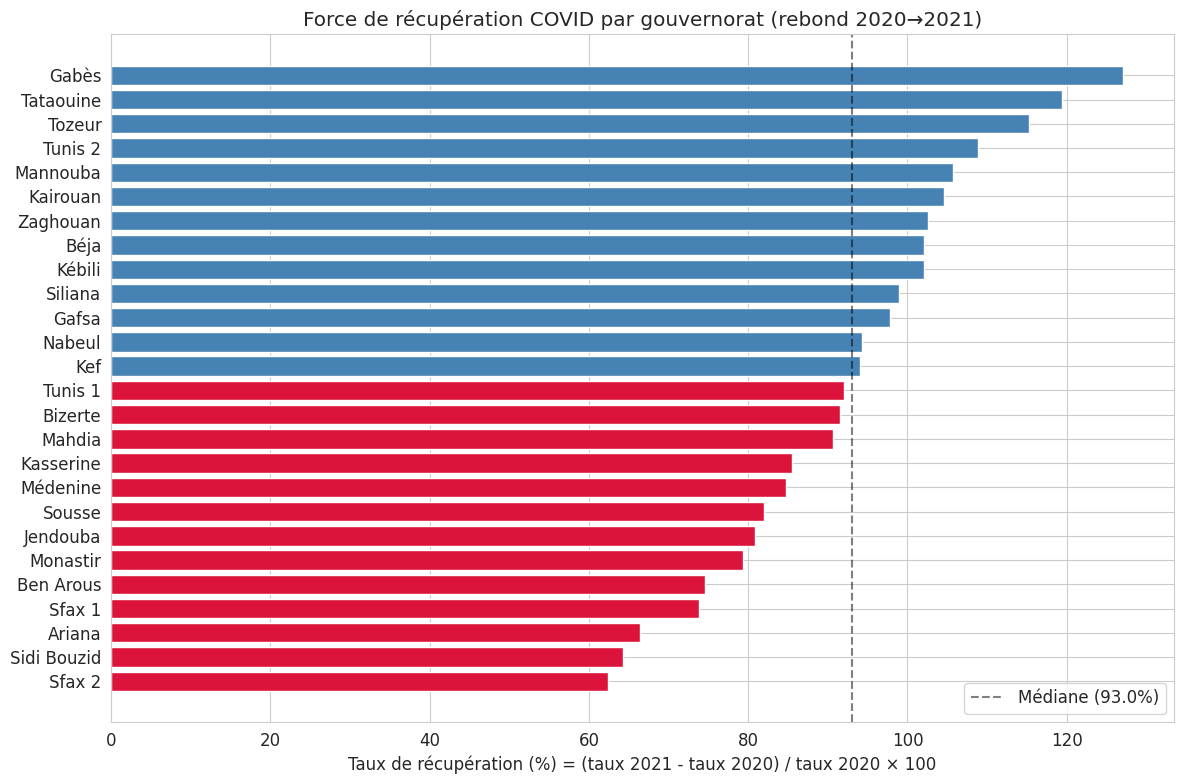

Corrélation récupération COVID / taux de pauvreté : 0.310
Interprétation : les gouvernorats plus pauvres ont rebondi PLUS fortement (effet de rattrapage)


In [21]:
covid_df = df_gov[['governorate', 'covid_recovery_pct', 'poverty_rate', 'mean_rate']].copy()
covid_df = covid_df.sort_values('covid_recovery_pct')

median_rec = covid_df['covid_recovery_pct'].median()
colors_bar = ['crimson' if x < median_rec else 'steelblue'
              for x in covid_df['covid_recovery_pct']]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(covid_df['governorate'], covid_df['covid_recovery_pct'],
        color=colors_bar, edgecolor='white')
ax.axvline(median_rec, color='black', linestyle='--', alpha=0.5, label=f'Médiane ({median_rec:.1f}%)')
ax.set_xlabel('Taux de récupération (%) = (taux 2021 - taux 2020) / taux 2020 × 100')
ax.set_title('Force de récupération COVID par gouvernorat (rebond 2020→2021)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/visualisations/02_covid_recovery.png', dpi=150)
plt.show()

corr_covid_poverty = df_gov['covid_recovery_pct'].corr(df_gov['poverty_rate'])
print(f'Corrélation récupération COVID / taux de pauvreté : {corr_covid_poverty:.3f}')
if corr_covid_poverty > 0.1:
    print('Interprétation : les gouvernorats plus pauvres ont rebondi PLUS fortement (effet de rattrapage)')
elif corr_covid_poverty < -0.1:
    print('Interprétation : les gouvernorats plus pauvres ont rebondi MOINS fortement (fragilité structurelle)')
else:
    print('Interprétation : pas de relation claire entre pauvreté et force de rebond COVID')

## 10. Sauvegarde des datasets pour les notebooks suivants

In [22]:
# Sauvegarde panel
df_panel.to_csv('../data/clean/bac_panel.csv', index=False)

# Sauvegarde cross-sectionnel (avec toutes les features engineered)
df_gov.to_csv('../data/clean/bac_crosssectional.csv', index=False)

print('✅ Fichiers sauvegardés :')
print(f'   data/bac_panel.csv          — {df_panel.shape[0]} lignes, 1 par gouvernorat × année')
print(f'   data/bac_crosssectional.csv — {df_gov.shape[0]} lignes, 1 par gouvernorat')
print(f'\nColonnes disponibles dans bac_crosssectional.csv :')
print(df_gov.columns.tolist())
print(f'\nColonnes disponibles dans bac_panel.csv :')
print(df_panel.columns.tolist())

✅ Fichiers sauvegardés :
   data/bac_panel.csv          — 208 lignes, 1 par gouvernorat × année
   data/bac_crosssectional.csv — 26 lignes, 1 par gouvernorat

Colonnes disponibles dans bac_crosssectional.csv :
['governorate', 'mean_rate', 'trend_slope', 'std_rate', 'min_rate', 'max_rate', 'best_rank', 'worst_rank', 'covid_recovery_pct', 'rank_volatility', 'nb_lycees', 'lycees_per_1k', 'poverty_rate', 'illiteracy_rate', 'population', 'predicted_rate', 'residual', 'outlier_type']

Colonnes disponibles dans bac_panel.csv :
['governorate', 'code', 'year', 'rank', 'success_rate', 'nb_lycees', 'lycees_per_1k', 'poverty_rate', 'illiteracy_rate', 'population', 'is_split_gov']


## Résumé des résultats

| Résultat | Valeur |
|---|---|
| Inégalité inter-gouvernorats | Voir cellule 5 |
| Corrélation la plus forte avec le taux de réussite | poverty_rate (~-0.83) |
| Sur-performants | Sfax 1, Sfax 2, Mahdia, Médenine |
| Sous-performants | Zaghouan, Tunis 2, Tozeur, Kébili, Gafsa |
| Gouvernorat le plus amélioré | Voir cellule 9 |

**Next:** Lancer `03_clustering_pattern_discovery.ipynb`